In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---------- Helpers ----------
def sanitize_columns(df):
    """Lowercase columns, replace spaces/punct with underscores, collapse repeats."""
    def fix(c):
        c = str(c).strip().lower()
        c = re.sub(r"[^\w\s]", "_", c)
        c = re.sub(r"\s+", "_", c)
        c = re.sub(r"_+", "_", c).strip("_")
        return c
    d = df.copy()
    d.columns = [fix(c) for c in d.columns]
    return d

def get_col(df, candidates):
    """Return the first existing column among candidates (case-insensitive, underscores)."""
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower()
        if key in cols:
            return cols[key]
    return None

def yes_no_to_bin(series):
    """Map yes/no-ish strings to 1/0; everything else -> NaN."""
    s = series.astype(str).str.strip().str.lower()
    map_yes = {"yes","y","true","1","oui"}
    map_no  = {"no","n","false","0","non"}
    return s.map(lambda x: 1 if x in map_yes else (0 if x in map_no else np.nan))

def gender_clean(series):
    """Normalize gender to Male/Female/Other."""
    s = series.astype(str).str.lower().str.strip()
    def norm(x):
        if any(k in x for k in ["trans","nonbinary","non-binary","genderqueer","fluid","agender","nb","other"]):
            return "Other"
        if x in ["m","male","man","cis male","cismale","boy"]:
            return "Male"
        if x in ["f","female","woman","cis female","cisfemale","girl"]:
            return "Female"
        if "male" in x:   return "Male"
        if "female" in x: return "Female"
        return "Other"
    return s.map(norm)

def parse_cgpa_maybe(series):
    """
    Try to coerce CGPA to numeric. If entries are ranges like '3.50-3.99',
    use the midpoint. Otherwise standard to_numeric coercion.
    """
    s = series.astype(str).str.strip()
    # range like '3.5 - 3.99'
    m = s.str.extract(r'(?P<lo>\d+(?:\.\d+)?)\s*[-–]\s*(?P<hi>\d+(?:\.\d+)?)')
    num = pd.to_numeric(series, errors="coerce")
    use_mid = m.notna().all(axis=1)
    num[use_mid] = (m.loc[use_mid, "lo"].astype(float) + m.loc[use_mid, "hi"].astype(float)) / 2.0
    # sometimes categories like 'Excellent', 'Good' -> leave NaN (will use counts)
    return num


In [2]:
from google.colab import files
uploaded = files.upload()  # select Student_Mental_health.csv

fname = list(uploaded.keys())[0]
raw = pd.read_csv(fname)
df = sanitize_columns(raw)
print("Loaded:", fname)
print("Shape:", df.shape)
df.head()


Saving Student_Mental_health.csv to Student_Mental_health.csv
Loaded: Student_Mental_health.csv
Shape: (101, 11)


,timestamp,choose_your_gender,age,what_is_your_course,your_current_year_of_study,what_is_your_cgpa,marital_status,do_you_have_depression,do_you_have_anxiety,do_you_have_panic_attack,did_you_seek_any_specialist_for_a_treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
# Candidate column names (lower/underscored)
col_gender    = get_col(df, ["choose_your_gender","gender"])
col_age       = get_col(df, ["age"])
col_cgpa      = get_col(df, ["cgpa","your_cgpa","cgpa_category","cgpa_categories","cgpa_categorized"])
col_dep       = get_col(df, ["do_you_have_depression","depression"])
col_anx       = get_col(df, ["do_you_have_anxiety","anxiety"])
col_panic     = get_col(df, ["do_you_have_panic_attack","panic_attacks","panic_attack"])

print("Detected columns:")
print(" gender  ->", col_gender)
print(" age     ->", col_age)
print(" cgpa    ->", col_cgpa)
print(" depress ->", col_dep)
print(" anxiety ->", col_anx)
print(" panic   ->", col_panic)

# Create cleaned/engineered columns (as available)
work = df.copy()

# Age (numeric)
if col_age is not None:
    work["age_num"] = pd.to_numeric(work[col_age], errors="coerce")

# CGPA numeric if possible (else remains NaN -> will use category counts in Ex1)
if col_cgpa is not None:
    work["cgpa_num"] = parse_cgpa_maybe(work[col_cgpa])

# Binary flags for mental health
if col_dep is not None:
    work["depression_bin"] = yes_no_to_bin(work[col_dep])
if col_anx is not None:
    work["anxiety_bin"] = yes_no_to_bin(work[col_anx])
if col_panic is not None:
    work["panic_bin"] = yes_no_to_bin(work[col_panic])

# Clean gender
if col_gender is not None:
    work["gender_clean"] = gender_clean(work[col_gender])

print("\nPreview of engineered columns:")
cols_show = [c for c in ["age_num","cgpa_num","gender_clean","depression_bin","anxiety_bin","panic_bin"] if c in work.columns]
display(work[cols_show].head())


Detected columns:
 gender  -> choose_your_gender
 age     -> age
 cgpa    -> None
 depress -> do_you_have_depression
 anxiety -> do_you_have_anxiety
 panic   -> do_you_have_panic_attack

Preview of engineered columns:


,age_num,gender_clean,depression_bin,anxiety_bin,panic_bin
0,18.0,Female,1,0,1
1,21.0,Male,0,1,0
2,19.0,Male,1,1,1
3,22.0,Female,1,0,0
4,23.0,Male,0,0,0


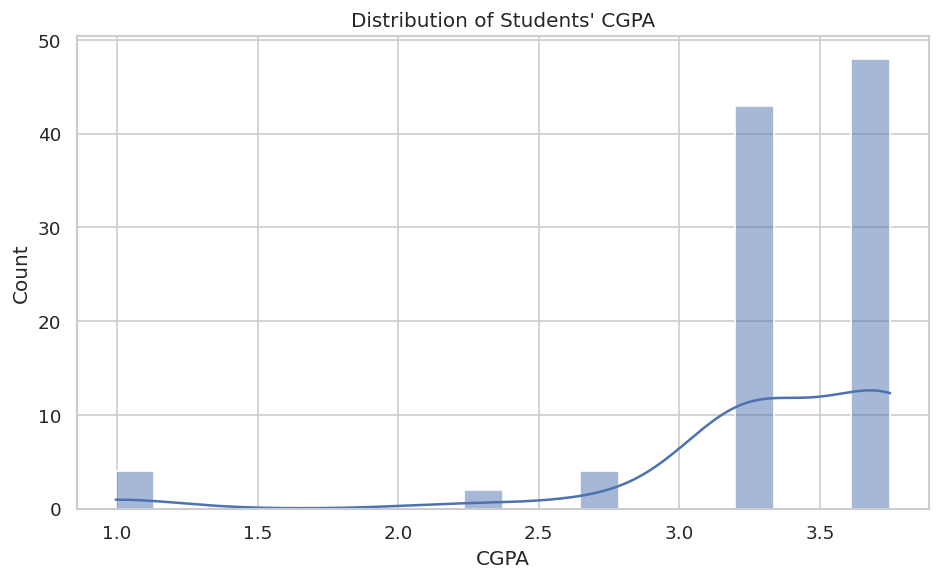

In [5]:
# Robust CGPA detection + histogram (numeric if possible, else categorical counts)

# 1) Try to ensure we have a numeric CGPA column
try:
    CGPA_COL_ORIG  # check if already defined
except NameError:
    CGPA_COL_ORIG = None

# If cgpa_num missing or empty, (re)detect CGPA source column
needs_detection = ("cgpa_num" not in work.columns) or (work["cgpa_num"].isna().all())
if needs_detection:
    # Prefer columns that explicitly contain 'cgpa'
    cand = [c for c in work.columns if re.search(r'(^|_)cgpa($|_)', c)]
    if not cand:
        # any column name containing 'cgpa'
        cand = [c for c in work.columns if "cgpa" in c]
    if not cand:
        # last resort: something with 'gpa'
        cand = [c for c in work.columns if re.search(r'gpa', c)]
    if cand:
        CGPA_COL_ORIG = cand[0]
        work["cgpa_num"] = parse_cgpa_maybe(work[CGPA_COL_ORIG])
    else:
        CGPA_COL_ORIG = None  # no cgpa-like column found

plt.figure(figsize=(8,5))

if ("cgpa_num" in work.columns) and work["cgpa_num"].notna().any():
    # Numeric CGPA path
    sns.histplot(data=work, x="cgpa_num", bins=20, kde=True)
    plt.xlabel("CGPA")
    plt.title("Distribution of Students' CGPA")
else:
    # Categorical CGPA path (counts per category)
    if CGPA_COL_ORIG is None:
        # Give a helpful message for debugging
        cols_hint = [c for c in work.columns if ("cgpa" in c) or ("gpa" in c)]
        raise ValueError(f"CGPA column not found. Columns containing 'cgpa'/'gpa' = {cols_hint}")
    order = (work[CGPA_COL_ORIG].value_counts(dropna=False)
                                .sort_index())
    sns.barplot(x=order.index, y=order.values, color="#4C78A8")
    plt.xlabel("CGPA category")
    plt.ylabel("Count")
    plt.title("Distribution of Students' CGPA (categories)")
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


/tmp/ipython-input-86816710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="gender_clean", y="anxiety_bin", estimator=np.mean, palette="Set2")


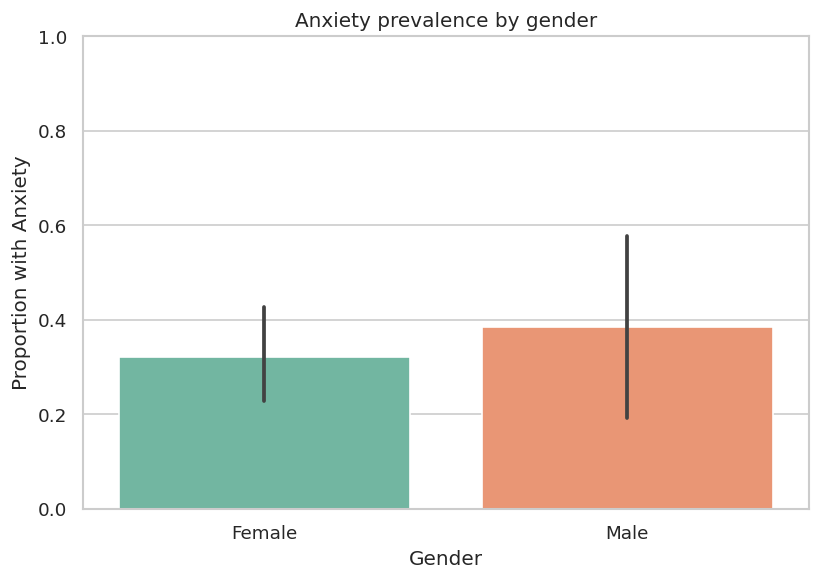

In [6]:
if ("gender_clean" not in work.columns) or ("anxiety_bin" not in work.columns):
    raise ValueError("Required columns for Exercise 2 not found (gender and anxiety).")

sub = work.dropna(subset=["gender_clean","anxiety_bin"]).copy()

plt.figure(figsize=(7,5))
sns.barplot(data=sub, x="gender_clean", y="anxiety_bin", estimator=np.mean, palette="Set2")
plt.ylabel("Proportion with Anxiety")
plt.xlabel("Gender")
plt.title("Anxiety prevalence by gender")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


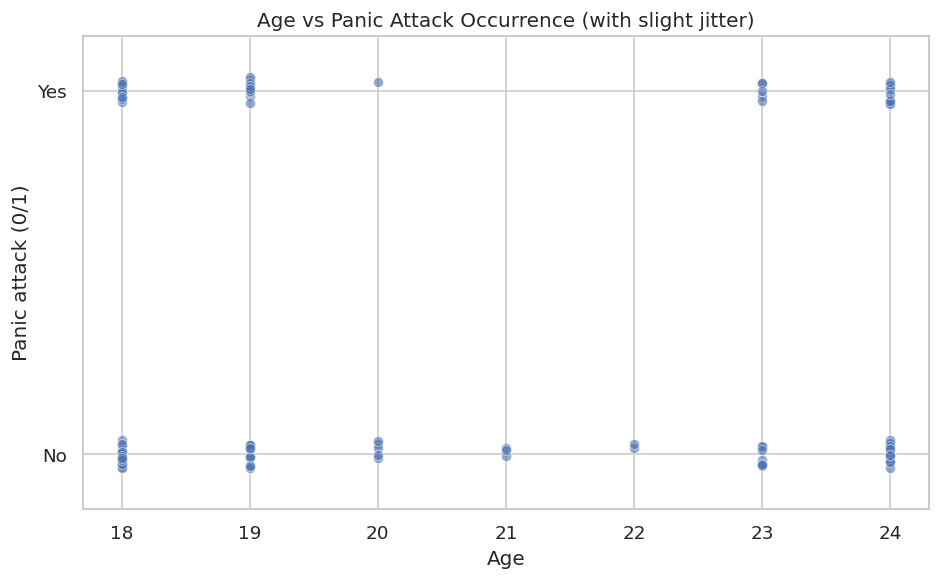

In [7]:
if ("age_num" not in work.columns) or ("panic_bin" not in work.columns):
    raise ValueError("Required columns for Exercise 3 not found (age and panic).")

rng = np.random.default_rng(42)
tmp = work.dropna(subset=["age_num","panic_bin"]).copy()
tmp["panic_jitter"] = tmp["panic_bin"] + rng.uniform(-0.04, 0.04, size=len(tmp))

plt.figure(figsize=(8,5))
sns.scatterplot(data=tmp, x="age_num", y="panic_jitter", alpha=0.6)
plt.yticks([0,1], ["No","Yes"])
plt.ylim(-0.15, 1.15)
plt.xlabel("Age")
plt.ylabel("Panic attack (0/1)")
plt.title("Age vs Panic Attack Occurrence (with slight jitter)")
plt.tight_layout()
plt.show()


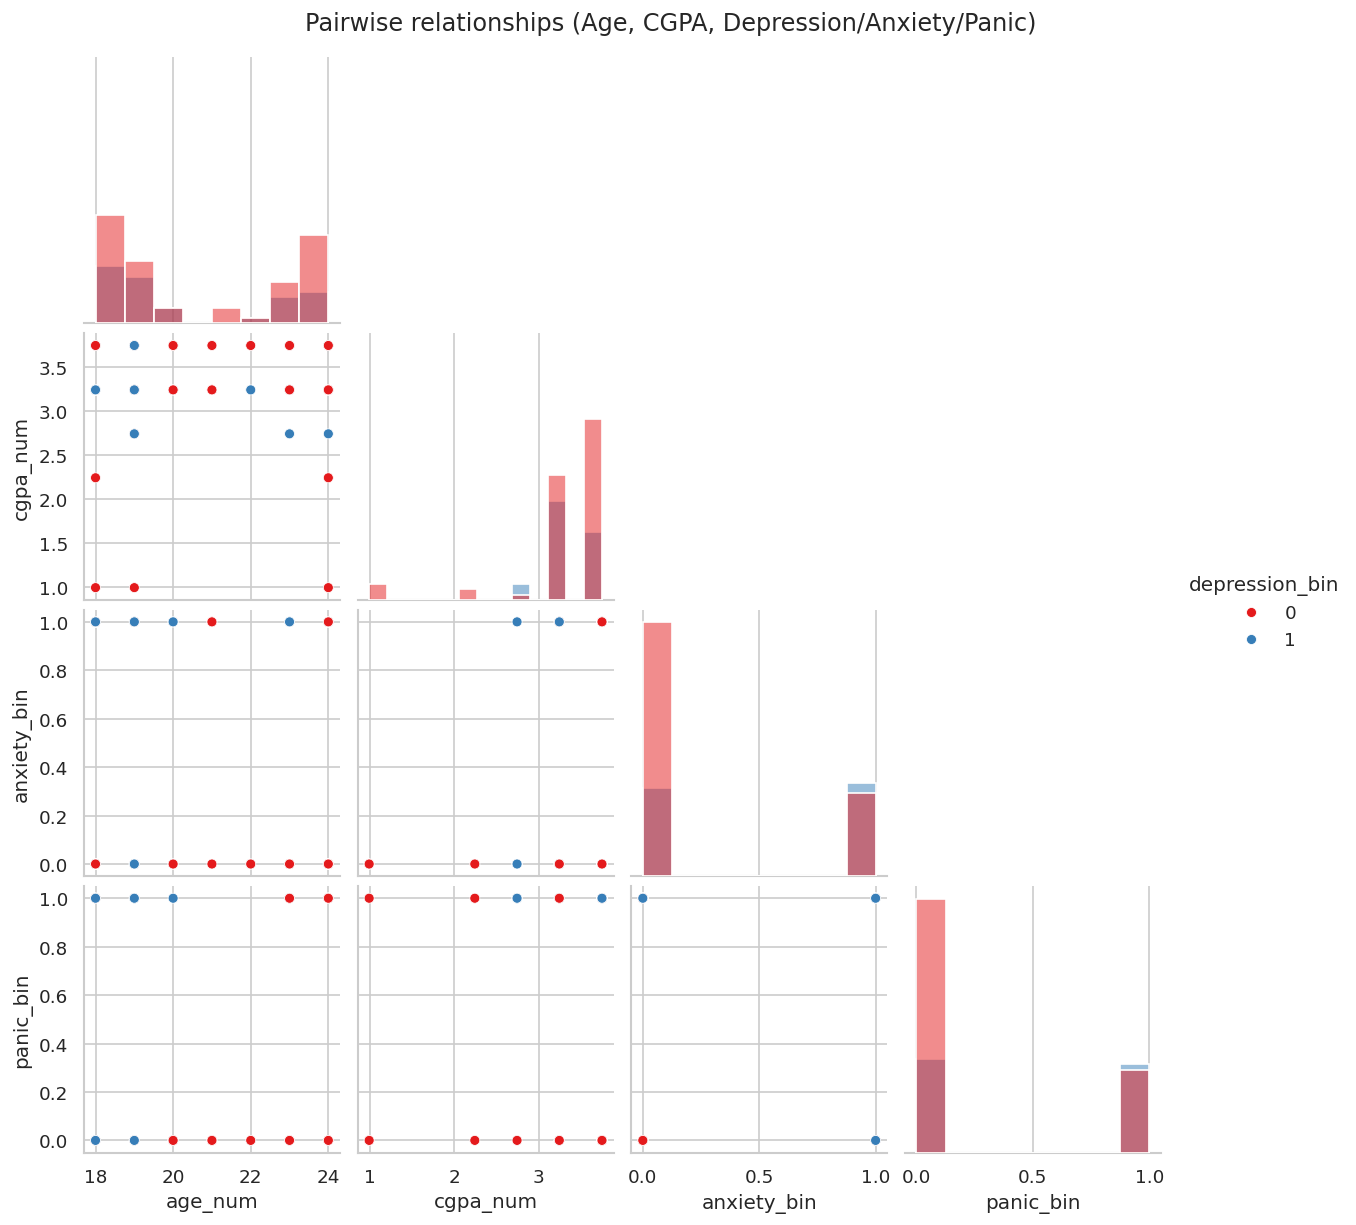

In [8]:
need = []
for c in ["age_num","cgpa_num","depression_bin","anxiety_bin","panic_bin"]:
    if c in work.columns:
        need.append(c)

if not set(["age_num","depression_bin","anxiety_bin","panic_bin"]).issubset(set(need)):
    raise ValueError("Not enough columns for pairplot. Ensure depression/anxiety/panic exist as Yes/No and age is present.")

pp = work[need].dropna()
hue = "depression_bin" if "depression_bin" in pp.columns else ("anxiety_bin" if "anxiety_bin" in pp.columns else "panic_bin")

sns.pairplot(pp, hue=hue, diag_kind="hist", corner=True, palette="Set1")
plt.suptitle("Pairwise relationships (Age, CGPA, Depression/Anxiety/Panic)", y=1.02)
plt.show()


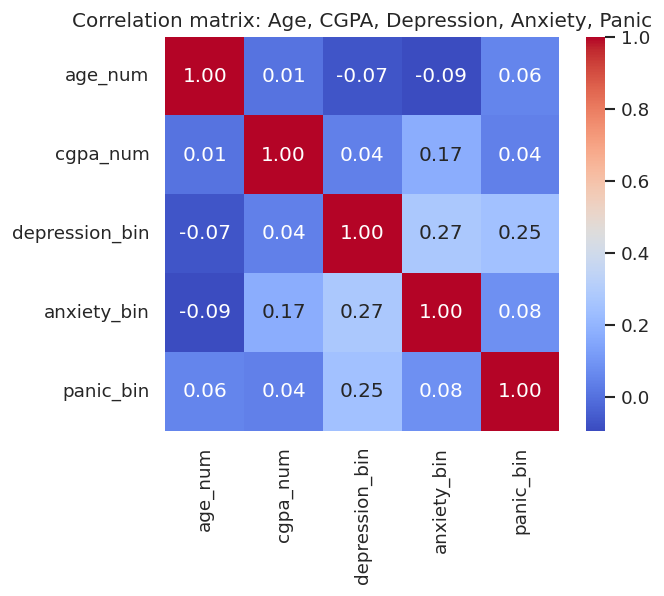

In [9]:
corr_cols = [c for c in ["age_num","cgpa_num","depression_bin","anxiety_bin","panic_bin"] if c in work.columns]
if len(corr_cols) < 3:
    raise ValueError("Need at least 3 numeric columns among age/cgpa/depression/anxiety/panic for heatmap.")

corr = work[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix: Age, CGPA, Depression, Anxiety, Panic")
plt.tight_layout()
plt.show()


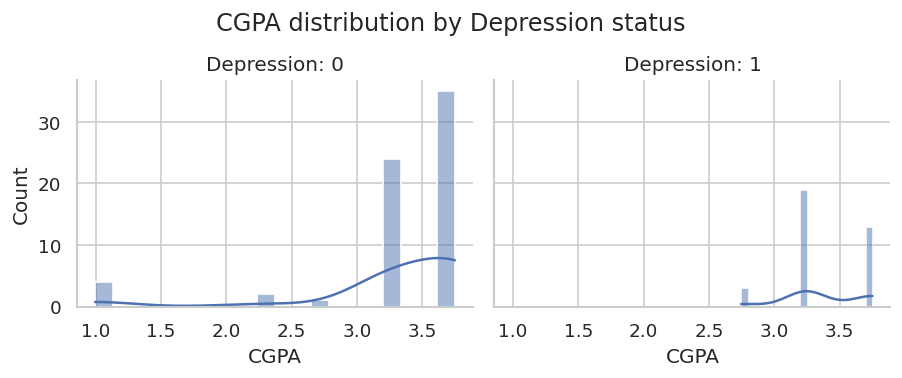

In [10]:
# Ensure we know which column to use if numeric CGPA is not available
try:
    CGPA_COL_ORIG
except NameError:
    CGPA_COL_ORIG = None
    # try to detect again quickly
    cand = [c for c in work.columns if re.search(r'(^|_)cgpa($|_)', c)] or \
           [c for c in work.columns if "cgpa" in c] or \
           [c for c in work.columns if "gpa" in c]
    if cand:
        CGPA_COL_ORIG = cand[0]

if ("depression_bin" not in work.columns):
    raise ValueError("Required column 'depression_bin' not found.")

# Numeric CGPA facet if available
if ("cgpa_num" in work.columns) and work["cgpa_num"].notna().any():
    fg = work.dropna(subset=["depression_bin","cgpa_num"]).copy()
    g = sns.FacetGrid(fg, col="depression_bin", sharex=True, sharey=True, height=3.2, aspect=1.2)
    g.map_dataframe(sns.histplot, x="cgpa_num", bins=20, kde=True)
    g.set_axis_labels("CGPA", "Count")
    g.set_titles(col_template="Depression: {col_name}")
    plt.subplots_adjust(top=0.8)
    g.fig.suptitle("CGPA distribution by Depression status")
    plt.show()
else:
    # Categorical CGPA fallback
    if CGPA_COL_ORIG is None:
        cols_hint = [c for c in work.columns if ("cgpa" in c) or ("gpa" in c)]
        raise ValueError(f"No CGPA column (numeric or categorical) available for FacetGrid. Candidates = {cols_hint}")
    fg = work.dropna(subset=["depression_bin", CGPA_COL_ORIG]).copy()
    g = sns.FacetGrid(fg, col="depression_bin", sharex=False, sharey=True, height=3.2, aspect=1.3)
    g.map_dataframe(sns.countplot, x=CGPA_COL_ORIG, order=sorted(fg[CGPA_COL_ORIG].astype(str).unique()))
    g.set_axis_labels("CGPA category", "Count")
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(30)
            label.set_ha("right")
    g.set_titles(col_template="Depression: {col_name}")
    plt.subplots_adjust(top=0.8)
    g.fig.suptitle("CGPA distribution by Depression status")
    plt.show()
